# Grid Imaging and Checking

Inspecting images of gridded data is a valuable way of checking for unusual or undesirable artefacts in the data and several functions are provided for this purpose. The main ones are shown here. Some checks are for delivered grids, and it is also possible to generate and image grids from the located data.

This example uses delivered grids from the Canobie Falcon survey and the Vinton Dome FTG survey.

Note that only grids in the `.ERS` format are able to be checked.

___

Import the required modules, and set the path to the geowhizz files.

In [1]:
from pathlib import Path
import AirGravQC as qc

In [2]:
data_root = r'./CanobieData/'

canobieHDF_file = Path(r'./CanobieData/Canobie.hdf5')
canobieHDF_plan = Path(r'./CanobieData/CanobiePlan.hdf5')

In [3]:
if not canobieHDF_file.exists():
    %run ./Prepare_CanobieData.ipynb

___

Ideally, the delivered grids from a survey should cover the same areal extent, have the same grid cell size, the same missing data value, the same geographic datum, and so forth. The **`checkErsHeaders`** function compares this information from the first `.ERS` file it encounters in the given directory with all the others, performing a quick and simple check for consistency.

In [ ]:
qc.checkErsHeaders(Path(data_root))

___

The **`imageAllInDir`** function images all `.ERS` grids found in the given directory, using the file name as the plot title. The images use the default color look up table and are shaded. This allows a very quick check that all the grids look okay.

In [4]:
gridfile = Path(data_root + r'FSF_GDD_2p67_final.ERS')

Found 8 .ers files ...
in: CanobieData


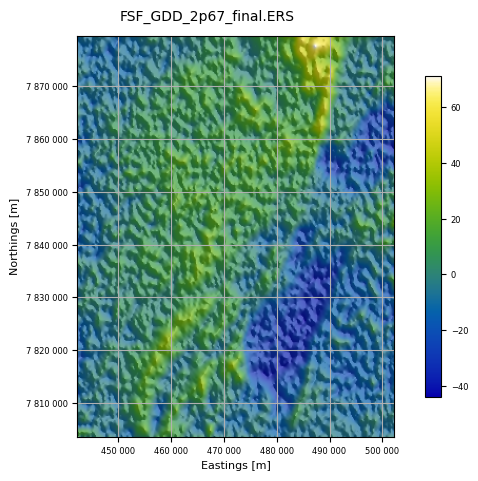

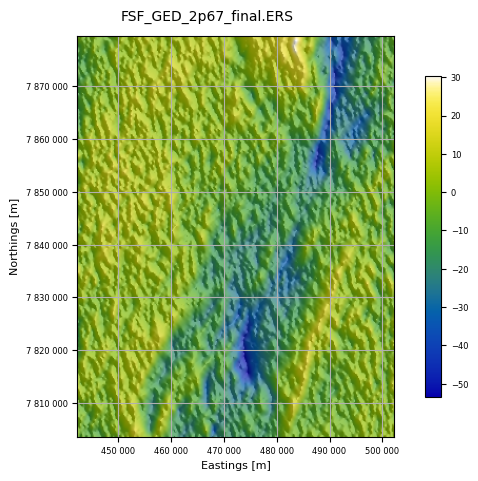

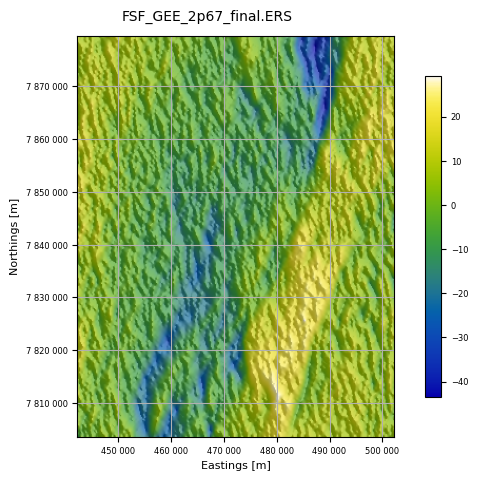

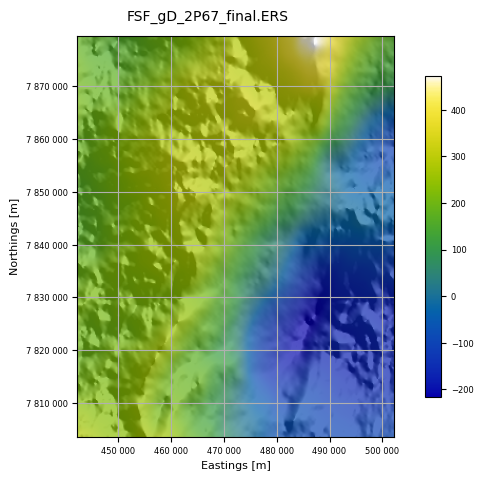

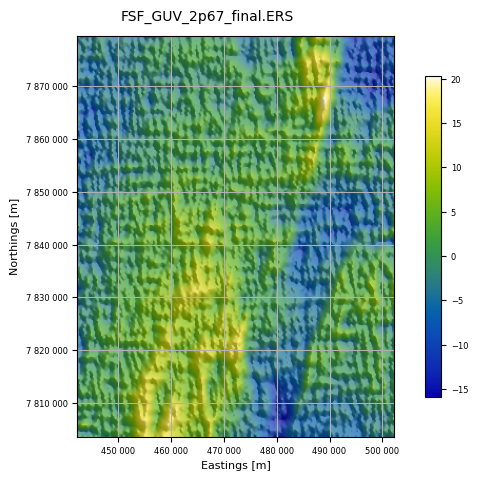

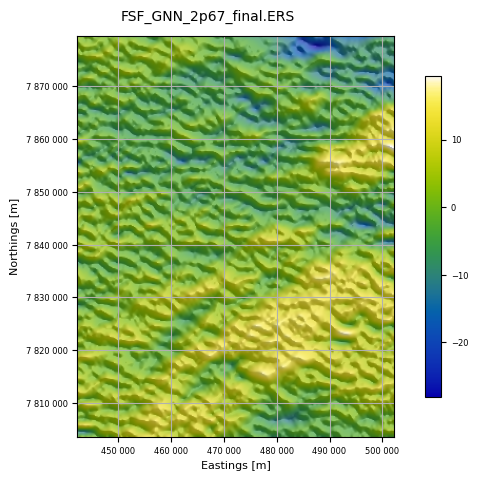

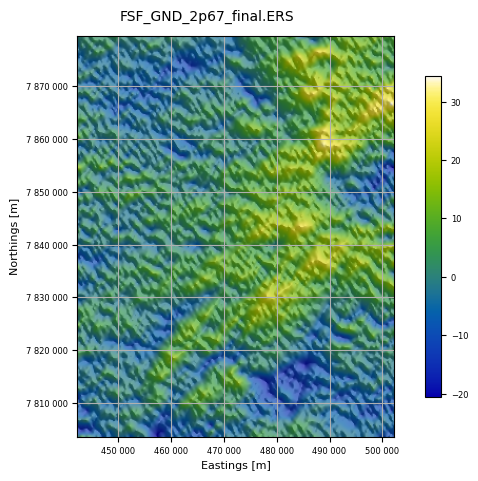

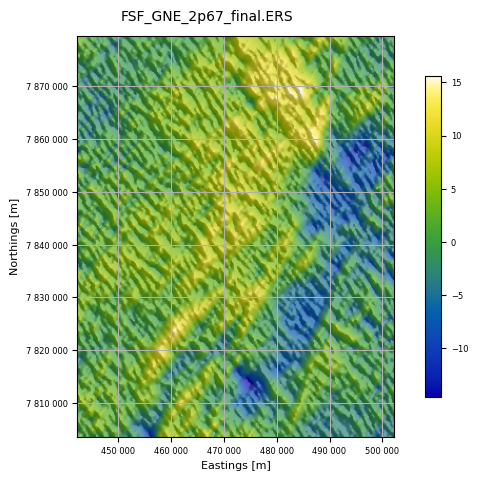

In [5]:
qc.imageAllInDir(Path(data_root))

___

Finally, we can use **`grid_n_image`** to create grids of any channels in the database and image them for viewing.
The Canobie located data cover a long and thin area somewhat unsuitable for imaging so we will grid and image the Vinton Dome data instead.

First, let us list the available channels. The default is to grid and image all channels in the database. For a demonstration, we only need a few.

In [6]:
vintonHDF_file = Path(r'./VintonData/VintonDome.hdf5')

In [7]:
if not vintonHDF_file.exists():
    %run ./Prepare_VintonDomeData.ipynb

In [8]:
qc.reportChannels(vintonHDF_file)

Whizz Version 1.0

28 channels:


28 channels:
 ['Altitude', 'Cross1_raw', 'Cross2_raw', 'Cross3_raw', 'Drape', 'HHMMSS', 'Inline1_raw', 'Inline2_raw', 'Inline3_raw', 'Lat', 'Lon', 'TC_Txx_100', 'TC_Txz_100', 'TC_Tyx_100', 'TC_Tyy_100', 'TC_Tyz_100', 'TC_Tzz_100', 'Terrain', 'Time', 'Txx_slv', 'Txz_slv', 'Tyx_slv', 'Tyy_slv', 'Tyz_slv', 'Tzz_slv', 'X', 'Y', 'YYMMDD']


Here `z_chans` is the list of channels to process. Those in `mr_chans` will have the mean value along each flight-line removed before gridding. Those in `d1_chans` will have the first difference along each flight-line gridded.

The first option is very useful for un-leveled data, and also for channels like heading, or velocity, which are strongly dependent on direction of flight.

The second option is very useful for data which are expected to vary uniformly with sample number.

Gridding and imaging Inline1_raw
91 lines; total number of fids in whizz file = 27865.
    Inline1_raw (mr): min = -72.3, max = 47.8, mean = -1.55E-15.

Processing (x, y, z) = (X, Y, MR_Inline1_raw). MR_Inline1_raw in eotvos.


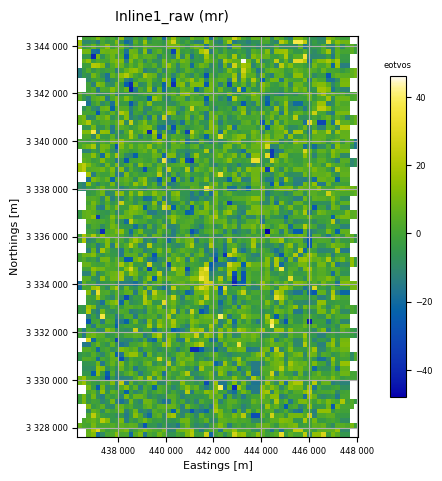

RMS of result = 10.34 eotvos
Array shape = (85, 60)
Gridding and imaging Inline2_raw
91 lines; total number of fids in whizz file = 27865.
    Inline2_raw: min = -658, max = -74.8, mean = -418.

Processing (x, y, z) = (X, Y, Inline2_raw). Inline2_raw in eotvos.


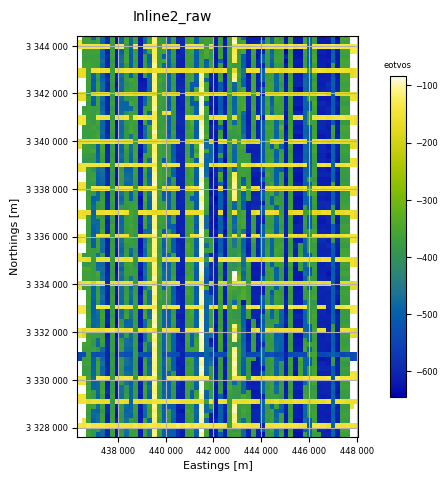

RMS of result = 161.24 eotvos
Array shape = (85, 60)
Gridding and imaging Tzz_slv
91 lines; total number of fids in whizz file = 27865.
    Tzz_slv: min = -86.1, max = 79.9, mean = 0.0023.

Processing (x, y, z) = (X, Y, Tzz_slv). Tzz_slv in eotvos.


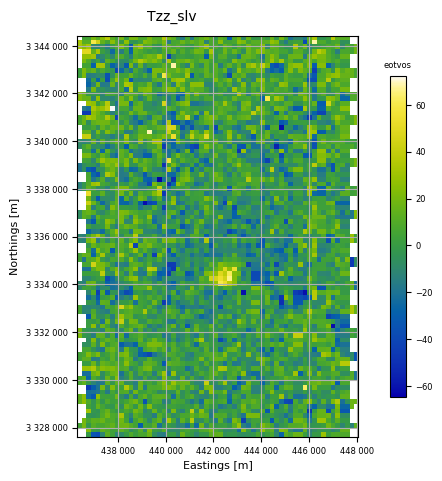

RMS of result = 15.78 eotvos
Array shape = (85, 60)
Gridding and imaging Terrain
91 lines; total number of fids in whizz file = 27865.
    Terrain: min = -3.87, max = 24.4, mean = 7.34.

Processing (x, y, z) = (X, Y, Terrain). Terrain in m.


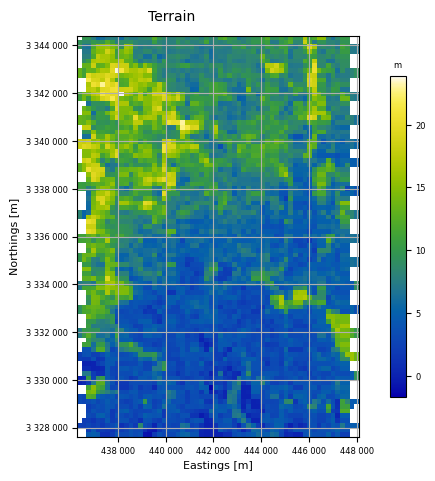

RMS of result = 4.29 m
Array shape = (85, 60)
Gridding and imaging Time
91 lines; total number of fids in whizz file = 27865.
    Time (d1): min = 1, max = 1, mean = 1.

Processing (x, y, z) = (X, Y, D1_Time). D1_Time in s.


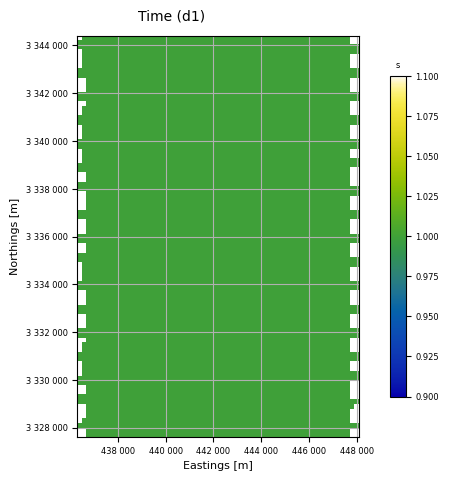

RMS of result = 0.00 s
Array shape = (85, 60)
Gridding and imaging Lat
91 lines; total number of fids in whizz file = 27865.
    Lat: min = 30.1, max = 30.2, mean = 30.2.

Processing (x, y, z) = (X, Y, Lat). Lat in degree.


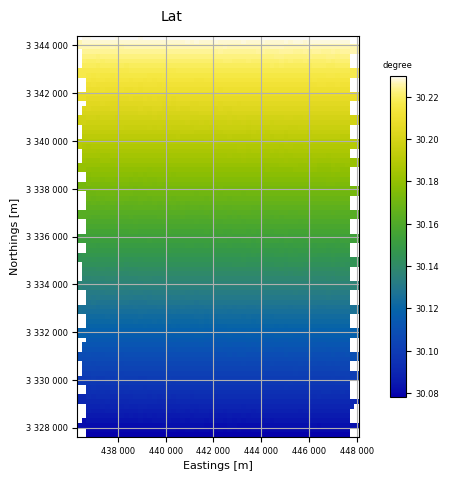

RMS of result = 0.04 degree
Array shape = (85, 60)


In [9]:
z_chans = ['Inline1_raw', 'Inline2_raw', 'Tzz_slv', 'Terrain', 'Time', 'Lat']
mr_chans = ['Inline1_raw']
d1_chans = ['Time']
qc.grid_n_image(vintonHDF_file, z_chans, 200.0, mr_chans=mr_chans, d1_chans=d1_chans)

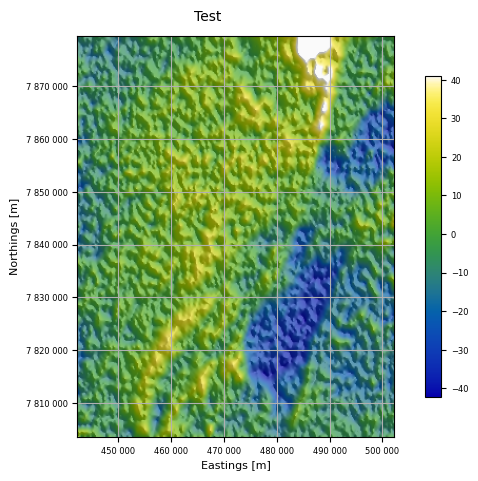

In [6]:
qc.display_grid(gridfile, "Test", colormap='geosoft', cmap_norm='nonorm', 
    cb_ticks='stats', nSigma=2,
    hs=True, azdeg=45)